# Modelos ML — Random Forest vs SVM sobre Embeddings CNN

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Librerías y configuración

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (
    RepeatedStratifiedKFold, cross_val_score,
    GridSearchCV, learning_curve
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)
from sklearn.manifold import TSNE
from scipy.stats import wilcoxon
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

# ── AJUSTA ESTA RUTA ──────────────────────────────────────────────
EMB_PATH    = '/content/drive/MyDrive/embeddings.csv'
# ─────────────────────────────────────────────────────────────────

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Repeated k-fold — 2 repeticiones x 5 folds (versión reducida)
N_SPLITS    = 5
N_REPEATS   = 2

print('✓ Librerías cargadas')
print(f'Estrategia CV: {N_REPEATS} repeticiones x {N_SPLITS} folds '
      f'= {N_REPEATS*N_SPLITS} evaluaciones por modelo')

✓ Librerías cargadas
Estrategia CV: 2 repeticiones x 5 folds = 10 evaluaciones por modelo


## 2. Carga de embeddings

Cargamos los embeddings generados por la CNN en el notebook 05.
Cada fila es un vector de 32 dimensiones que representa un momento de medición fisiológica.

In [16]:
df_emb = pd.read_csv(EMB_PATH)

print(f'Shape: {df_emb.shape}')
print(f'Columnas: {list(df_emb.columns[:5])} ... {list(df_emb.columns[-3:])}')

# Separar features y etiquetas
emb_cols = [c for c in df_emb.columns if c.startswith('emb_')]
X        = df_emb[emb_cols].values.astype(np.float32)

# Manejar etiquetas — pueden ser numéricas o strings
if 'stress_label' in df_emb.columns:
    y_raw = df_emb['stress_label'].values
    # Si son numéricos, mapear a strings
    if df_emb['stress_label'].dtype != object:
        mapa = {0: 'S1', 1: 'S2', 2: 'S3'}
        y_raw = np.array([mapa.get(int(v), str(v)) for v in y_raw])
else:
    y_raw = df_emb['label_enc'].values
    mapa  = {0: 'S1', 1: 'S2', 2: 'S3'}
    y_raw = np.array([mapa[int(v)] for v in y_raw])

# Codificar para sklearn
le = LabelEncoder()
y  = le.fit_transform(y_raw)

print(f'\nFeatures (embeddings): {X.shape}')
print(f'Clases: {le.classes_}')
print(f'\nDistribución:')
for i, cls in enumerate(le.classes_):
    n   = (y == i).sum()
    pct = n / len(y) * 100
    print(f'  {cls}: {n} ({pct:.1f}%)')

Shape: (770, 34)
Columnas: ['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4'] ... ['emb_31', 'label_enc', 'stress_label']

Features (embeddings): (770, 32)
Clases: ['S1' 'S2' 'S3']

Distribución:
  S1: 443 (57.5%)
  S2: 220 (28.6%)
  S3: 107 (13.9%)


## 3. Pipelines sklearn

Definimos un pipeline por modelo. El pipeline asegura que la normalización
se aprenda solo en el train set y se aplique al test — evita data leakage.

In [17]:
# Pipeline A — Random Forest
# No necesita normalización pero la incluimos por consistencia
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(
        class_weight = 'balanced',   # maneja desbalance S1>S2>S3
        random_state = RANDOM_SEED,
        n_jobs       = -1
    ))
])

# Pipeline B — SVM
# SVM SÍ necesita normalización — sensible a escala
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(
        class_weight = 'balanced',
        random_state = RANDOM_SEED,
        probability  = True          # para obtener probabilidades
    ))
])

print('Pipeline A — Random Forest:')
print(pipeline_rf)
print('\nPipeline B — SVM:')
print(pipeline_svm)

Pipeline A — Random Forest:
Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

Pipeline B — SVM:
Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 SVC(class_weight='balanced', probability=True,
                     random_state=42))])


## 4. Optimización de hiperparámetros

Usamos GridSearchCV con repeated k-fold para encontrar los mejores
hiperparámetros de cada modelo. Métrica: F1-macro (balanceada entre clases).

In [18]:
# CV para optimización
cv_opt = RepeatedStratifiedKFold(
    n_splits   = N_SPLITS,
    n_repeats  = N_REPEATS,
    random_state = RANDOM_SEED
)

# ── Grid Random Forest ─────────────────────────────────────────
param_grid_rf = {
    'clf__n_estimators'    : [25, 50, 75, 100, 150, 200],  # 6 puntos
    'clf__max_depth'       : [None, 3, 5, 10],
    'clf__min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv      = cv_opt,
    scoring = 'f1_macro',
    n_jobs  = -1,
    verbose = 1
)

print('Optimizando Random Forest...')
grid_rf.fit(X, y)

print(f'\n✓ Mejores parámetros RF:')
for k, v in grid_rf.best_params_.items():
    print(f'  {k}: {v}')
print(f'  F1-macro CV: {grid_rf.best_score_:.4f}')

Optimizando Random Forest...
Fitting 10 folds for each of 48 candidates, totalling 480 fits

✓ Mejores parámetros RF:
  clf__max_depth: 5
  clf__min_samples_split: 2
  clf__n_estimators: 25
  F1-macro CV: 0.3461


In [19]:
# ── Grid SVM ──────────────────────────────────────────────────
param_grid_svm = {
    'clf__C'      : [0.01, 0.1, 0.5, 1, 5, 10, 50],  # 7 puntos
    'clf__kernel' : ['rbf', 'linear'],
    'clf__gamma'  : ['scale', 'auto']
}

grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid_svm,
    cv      = cv_opt,
    scoring = 'f1_macro',
    n_jobs  = -1,
    verbose = 1
)

print('Optimizando SVM...')
grid_svm.fit(X, y)

print(f'\n✓ Mejores parámetros SVM:')
for k, v in grid_svm.best_params_.items():
    print(f'  {k}: {v}')
print(f'  F1-macro CV: {grid_svm.best_score_:.4f}')

Optimizando SVM...
Fitting 10 folds for each of 28 candidates, totalling 280 fits

✓ Mejores parámetros SVM:
  clf__C: 10
  clf__gamma: scale
  clf__kernel: rbf
  F1-macro CV: 0.3420


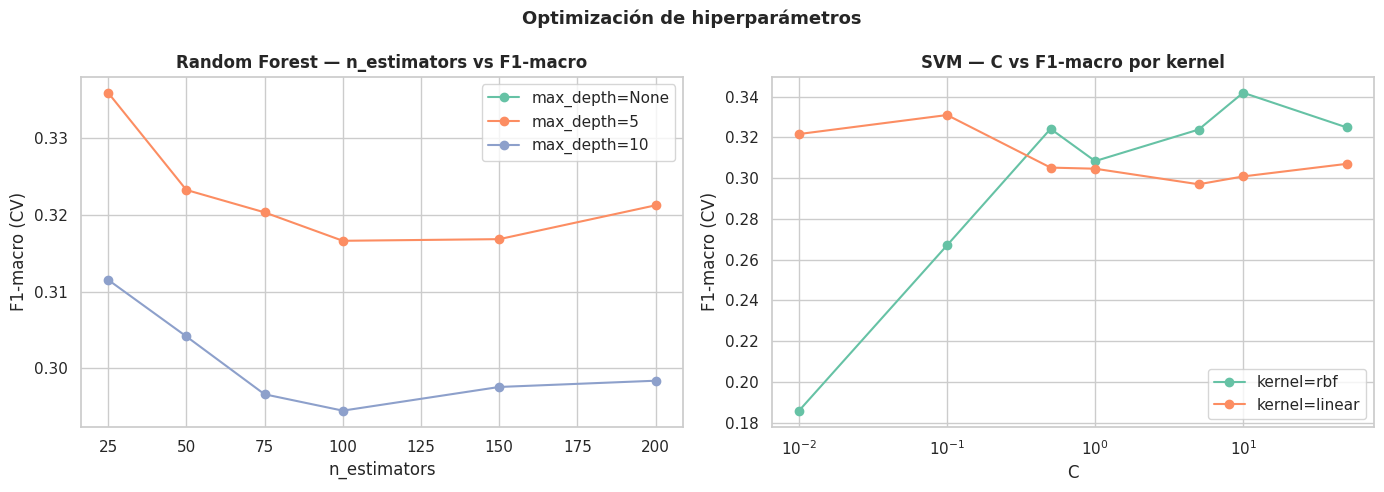

In [20]:
# Visualizar optimización de hiperparámetros — RF
resultados_rf = pd.DataFrame(grid_rf.cv_results_)

# Gráfica: n_estimators vs F1 para cada max_depth
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for depth in [None, 5, 10]:
    mask = resultados_rf['param_clf__max_depth'] == depth
    sub  = resultados_rf[mask].groupby(
        'param_clf__n_estimators'
    )['mean_test_score'].mean()
    axes[0].plot(sub.index, sub.values,
                 marker='o', label=f'max_depth={depth}')

axes[0].set_title('Random Forest — n_estimators vs F1-macro',
                  fontweight='bold')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('F1-macro (CV)')
axes[0].legend()

# Gráfica: C vs F1 para SVM por kernel
resultados_svm = pd.DataFrame(grid_svm.cv_results_)
for kernel in ['rbf', 'linear']:
    mask = resultados_svm['param_clf__kernel'] == kernel
    sub  = resultados_svm[mask].groupby(
        'param_clf__C'
    )['mean_test_score'].mean()
    axes[1].plot(sub.index, sub.values,
                 marker='o', label=f'kernel={kernel}')

axes[1].set_title('SVM — C vs F1-macro por kernel',
                  fontweight='bold')
axes[1].set_xlabel('C')
axes[1].set_ylabel('F1-macro (CV)')
axes[1].set_xscale('log')
axes[1].legend()

fig.suptitle('Optimización de hiperparámetros',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('hiperparametros.png', bbox_inches='tight')
plt.show()

## 5. Evaluación con repeated k-fold

Evaluamos los mejores modelos con repeated k-fold para obtener
una distribución de scores — necesaria para el test de Wilcoxon.

In [21]:
# Mejores modelos tras optimización
best_rf  = grid_rf.best_estimator_
best_svm = grid_svm.best_estimator_

# CV final con los mejores modelos
cv_final = RepeatedStratifiedKFold(
    n_splits     = N_SPLITS,
    n_repeats    = N_REPEATS,
    random_state = RANDOM_SEED
)

print('Evaluando modelos con repeated k-fold...')

scores_rf = cross_val_score(
    best_rf, X, y,
    cv      = cv_final,
    scoring = 'f1_macro',
    n_jobs  = -1
)

scores_svm = cross_val_score(
    best_svm, X, y,
    cv      = cv_final,
    scoring = 'f1_macro',
    n_jobs  = -1
)

print(f'\nRandom Forest  — F1-macro: {scores_rf.mean():.4f} ± {scores_rf.std():.4f}')
print(f'SVM            — F1-macro: {scores_svm.mean():.4f} ± {scores_svm.std():.4f}')
print(f'\nScores RF  ({len(scores_rf)}  folds): {scores_rf.round(4)}')
print(f'Scores SVM ({len(scores_svm)} folds): {scores_svm.round(4)}')

Evaluando modelos con repeated k-fold...

Random Forest  — F1-macro: 0.3461 ± 0.0601
SVM            — F1-macro: 0.3420 ± 0.0490

Scores RF  (10  folds): [0.3415 0.3911 0.3689 0.4242 0.3246 0.2772 0.3175 0.3916 0.2199 0.4048]
Scores SVM (10 folds): [0.3234 0.4096 0.3018 0.4193 0.3469 0.3603 0.3328 0.3606 0.24   0.3251]


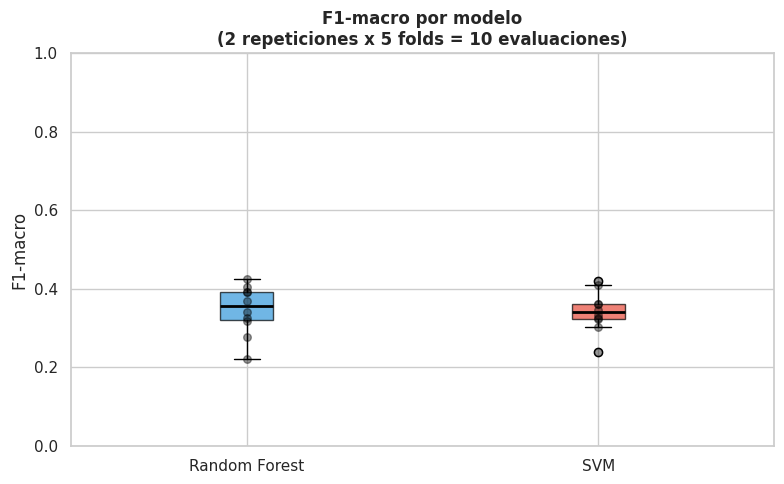

In [22]:
# Boxplot de scores por modelo
fig, ax = plt.subplots(figsize=(8, 5))

data_box = [scores_rf, scores_svm]
bp = ax.boxplot(data_box,
                labels=['Random Forest', 'SVM'],
                patch_artist=True,
                medianprops={'color':'black','linewidth':2})

colores_box = ['#3498db', '#e74c3c']
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Agregar puntos individuales
for i, scores in enumerate([scores_rf, scores_svm], 1):
    ax.scatter([i]*len(scores), scores,
               color='black', alpha=0.4, s=30, zorder=3)

ax.set_title(f'F1-macro por modelo\n'
             f'({N_REPEATS} repeticiones x {N_SPLITS} folds = '
             f'{N_REPEATS*N_SPLITS} evaluaciones)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('F1-macro')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('scores_boxplot.png', bbox_inches='tight')
plt.show()

## 6. Comparación estadística — Test de Wilcoxon

El test de Wilcoxon compara si la diferencia entre los scores de los dos modelos
es estadísticamente significativa. Es el test no paramétrico recomendado para
comparar clasificadores en ML (Demšar, 2006).

- H0: no hay diferencia significativa entre RF y SVM
- H1: hay diferencia significativa
- Nivel de significancia: α = 0.05

In [24]:
stat, p_value = wilcoxon(scores_rf, scores_svm)

print('=' * 50)
print('TEST DE WILCOXON — RF vs SVM')
print('=' * 50)
print(f'\n  Estadístico W: {stat:.4f}')
print(f'  p-value:       {p_value:.4f}')
print(f'\n  Random Forest  — F1: {scores_rf.mean():.4f} ± {scores_rf.std():.4f}')
print(f'  SVM            — F1: {scores_svm.mean():.4f} ± {scores_svm.std():.4f}')

alpha = 0.05
if p_value < alpha:
    mejor = 'Random Forest' if scores_rf.mean() > scores_svm.mean() else 'SVM'
    print(f'\n  ✓ Diferencia SIGNIFICATIVA (p < {alpha})')
    print(f'  → {mejor} es estadísticamente superior')
else:
    print(f'\n  ~ Diferencia NO significativa (p >= {alpha})')
    print(f'  → No hay evidencia suficiente para preferir un modelo')
    print(f'  → Se recomienda el más simple o interpretable')

TEST DE WILCOXON — RF vs SVM

  Estadístico W: 27.0000
  p-value:       1.0000

  Random Forest  — F1: 0.3461 ± 0.0601
  SVM            — F1: 0.3420 ± 0.0490

  ~ Diferencia NO significativa (p >= 0.05)
  → No hay evidencia suficiente para preferir un modelo
  → Se recomienda el más simple o interpretable


## 7. Curvas de aprendizaje

Las curvas de aprendizaje muestran cómo mejora el modelo con más datos de entrenamiento.
Si train y val convergen → el modelo generaliza bien.
Si hay brecha grande → overfitting.

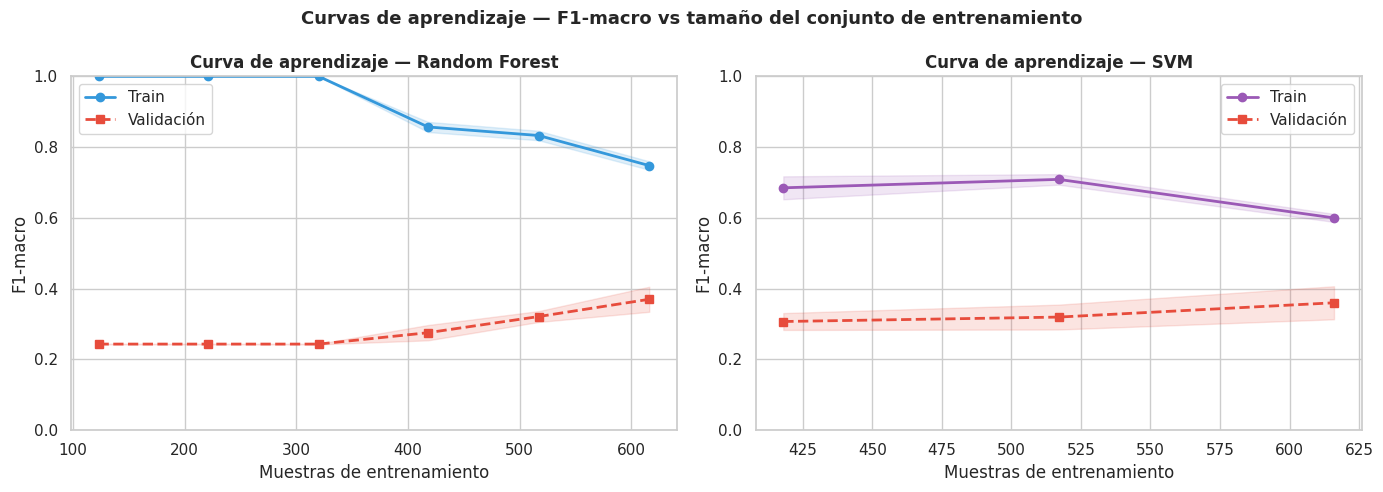

In [25]:
def plot_learning_curve(estimator, X, y, titulo, ax, color='#3498db'):
    """Grafica la curva de aprendizaje de un estimador."""
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        cv          = RepeatedStratifiedKFold(
            n_splits=N_SPLITS, n_repeats=1,
            random_state=RANDOM_SEED
        ),
        scoring     = 'f1_macro',
        train_sizes = np.linspace(0.2, 1.0, 6),
        n_jobs      = -1
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-',
            color=color, label='Train', linewidth=2)
    ax.fill_between(train_sizes,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.15, color=color)

    ax.plot(train_sizes, val_mean, 's--',
            color='#e74c3c', label='Validación', linewidth=2)
    ax.fill_between(train_sizes,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.15, color='#e74c3c')

    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Muestras de entrenamiento')
    ax.set_ylabel('F1-macro')
    ax.set_ylim(0, 1)
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_learning_curve(best_rf,  X, y,
                    'Curva de aprendizaje — Random Forest',
                    axes[0], color='#3498db')
plot_learning_curve(best_svm, X, y,
                    'Curva de aprendizaje — SVM',
                    axes[1], color='#9b59b6')

fig.suptitle('Curvas de aprendizaje — F1-macro vs tamaño del conjunto de entrenamiento',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('curvas_aprendizaje.png', bbox_inches='tight')
plt.show()

## 8. Reporte de clasificación y matriz de confusión

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    stratify=y, random_state=RANDOM_SEED
)

# Entrenar y predecir
best_rf.fit(X_train, y_train)
best_svm.fit(X_train, y_train)

y_pred_rf  = best_rf.predict(X_test)
y_pred_svm = best_svm.predict(X_test)

print('RANDOM FOREST:')
print(classification_report(
    y_test, y_pred_rf,
    target_names=le.classes_
))

print('SVM:')
print(classification_report(
    y_test, y_pred_svm,
    target_names=le.classes_
))

RANDOM FOREST:
              precision    recall  f1-score   support

          S1       0.59      0.65      0.62        89
          S2       0.23      0.20      0.21        44
          S3       0.19      0.14      0.16        21

    accuracy                           0.45       154
   macro avg       0.33      0.33      0.33       154
weighted avg       0.43      0.45      0.44       154

SVM:
              precision    recall  f1-score   support

          S1       0.59      0.54      0.56        89
          S2       0.20      0.18      0.19        44
          S3       0.15      0.24      0.19        21

    accuracy                           0.40       154
   macro avg       0.31      0.32      0.31       154
weighted avg       0.42      0.40      0.41       154



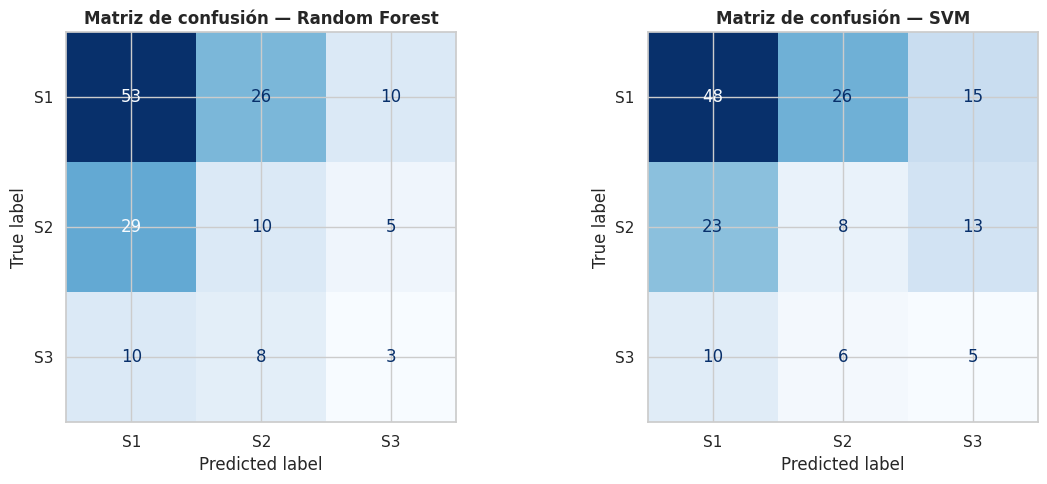

In [13]:
# Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, titulo in zip(
        axes,
        [y_pred_rf, y_pred_svm],
        ['Random Forest', 'SVM']):

    cm  = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=le.classes_
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de confusión — {titulo}',
                 fontweight='bold')

plt.tight_layout()
plt.savefig('matrices_confusion.png', bbox_inches='tight')
plt.show()

## 9. Resumen final

In [14]:
print('=' * 55)
print('RESUMEN FINAL — Comparación RF vs SVM')
print('=' * 55)
print(f"""
  Embeddings usados:   {X.shape[0]} muestras x {X.shape[1]} dims
  Estrategia CV:       {N_REPEATS} rep x {N_SPLITS} folds
  Métrica:             F1-macro

  Random Forest:
    Mejores params:    {grid_rf.best_params_}
    F1-macro CV:       {scores_rf.mean():.4f} ± {scores_rf.std():.4f}

  SVM:
    Mejores params:    {grid_svm.best_params_}
    F1-macro CV:       {scores_svm.mean():.4f} ± {scores_svm.std():.4f}

  Wilcoxon p-value:    {p_value:.4f}
  Conclusión:          {'Diferencia SIGNIFICATIVA' if p_value < 0.05 else 'Sin diferencia significativa'}


RESUMEN FINAL — Comparación RF vs SVM

  Embeddings usados:   770 muestras x 32 dims
  Estrategia CV:       2 rep x 5 folds
  Métrica:             F1-macro

  Random Forest:
    Mejores params:    {'clf__max_depth': 5, 'clf__min_samples_split': 2, 'clf__n_estimators': 50}
    F1-macro CV:       0.3292 ± 0.0430

  SVM:
    Mejores params:    {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
    F1-macro CV:       0.3420 ± 0.0490

  Wilcoxon p-value:    0.2324
  Conclusión:          Sin diferencia significativa

  Archivos generados:
    hiperparametros.png
    scores_boxplot.png
    curvas_aprendizaje.png
    matrices_confusion.png

